In [10]:
import pandas as pd
import numpy as np
import sklearn as sk
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from pathlib import Path

PROJECT_ROOT = Path(r"C:\Users\cucumber\Desktop\Learnng\AI Agent\ai_agent_memerea\homeworks\HW06")  # ← замените на ваш реальный путь
FIG_DIR = PROJECT_ROOT / "artifacts" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

In [11]:
df = pd.read_csv('S06-hw-dataset-04.csv')

In [12]:
display(df.head())
df.info()
display(df.describe())
df.shape

,id,f01,f02,f03,f04,f05,f06,f07,f08,f09,...,f52,f53,f54,f55,f56,f57,f58,f59,f60,target
0,1,-1.250210,1.423474,-0.225004,-4.023138,-0.832729,-0.550874,1.772090,2.761690,-0.698750,...,10.938269,0.501178,1.600001,0.314212,1.209735,1.355697,-5.338924,1.153944,-0.153934,0
1,2,0.074328,0.376429,0.212831,-0.502074,2.017405,0.625496,1.943785,1.242030,-0.524090,...,7.775262,-4.550195,6.272586,-0.932162,-0.228543,1.735220,-3.827828,0.292165,0.273720,0
2,3,0.638481,0.060968,0.746760,2.479653,-0.292858,-0.078139,-2.918423,-0.013186,1.009135,...,-4.448447,-9.593179,-3.093519,0.029321,0.605511,0.829103,-0.085985,2.891408,0.766221,0
3,4,1.712916,-1.350969,-0.256473,1.622074,-0.445141,0.911932,-3.440345,1.505192,-1.104348,...,-1.619072,-3.237479,-5.474038,-1.582475,0.198137,3.823409,0.880395,1.148610,0.136732,0
4,5,0.905676,-0.206545,-0.068806,4.086026,-1.010045,-0.772644,-4.207688,2.506104,1.589143,...,-2.396844,-10.540129,-5.532811,-1.231203,0.000119,4.298572,-1.558235,0.924673,0.111668,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 62 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   id      25000 non-null  int64  
 1   f01     25000 non-null  float64
 2   f02     25000 non-null  float64
 3   f03     25000 non-null  float64
 4   f04     25000 non-null  float64
 5   f05     25000 non-null  float64
 6   f06     25000 non-null  float64
 7   f07     25000 non-null  float64
 8   f08     25000 non-null  float64
 9   f09     25000 non-null  float64
 10  f10     25000 non-null  float64
 11  f11     25000 non-null  float64
 12  f12     25000 non-null  float64
 13  f13     25000 non-null  float64
 14  f14     25000 non-null  float64
 15  f15     25000 non-null  float64
 16  f16     25000 non-null  float64
 17  f17     25000 non-null  float64
 18  f18     25000 non-null  float64
 19  f19     25000 non-null  float64
 20  f20     25000 non-null  float64
 21  f21     25000 non-null  float64
 22

,id,f01,f02,f03,f04,f05,f06,f07,f08,f09,...,f52,f53,f54,f55,f56,f57,f58,f59,f60,target
count,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,...,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.00000
mean,12500.500000,-0.000386,-0.004872,0.003202,0.335329,-0.000563,-0.010118,0.001182,0.957385,-0.004658,...,-0.166251,-3.387506,1.749793,-0.013017,-0.001383,0.893365,-0.909479,0.000570,-0.000754,0.04920
std,7217.022701,1.001623,0.995606,1.004367,3.207537,0.993965,1.002172,2.432162,1.830223,1.013470,...,4.234741,4.331576,5.318660,1.001594,0.996409,2.445185,1.962618,0.994320,0.997167,0.21629
min,1.000000,-4.370993,-4.087073,-4.103875,-13.249937,-4.118778,-3.895974,-8.883224,-8.132548,-4.068933,...,-20.021141,-18.332290,-20.336666,-4.349216,-4.119472,-9.508509,-7.919287,-4.038312,-3.812255,0.00000
25%,6250.750000,-0.680165,-0.675100,-0.675426,-1.750048,-0.669764,-0.674374,-1.647977,-0.217260,-0.688278,...,-2.897904,-6.278403,-1.775889,-0.689962,-0.676191,-0.735473,-2.226959,-0.666367,-0.665861,0.00000
50%,12500.500000,0.001859,-0.000247,0.013272,0.403483,-0.001309,-0.005994,-0.011349,0.963009,0.000414,...,-0.396946,-3.462072,1.931851,-0.020933,-0.004193,0.888535,-0.923354,0.004381,0.002420,0.00000
75%,18750.250000,0.679702,0.659523,0.683437,2.486453,0.672299,0.652629,1.658680,2.167758,0.681040,...,2.344956,-0.578540,5.473886,0.661300,0.673722,2.516790,0.395648,0.666474,0.665918,0.00000
max,25000.000000,4.208888,3.984564,3.793442,15.288250,4.020733,4.279607,9.538525,9.321099,4.261349,...,20.717964,18.818764,20.688069,4.338337,3.902131,11.880651,6.778980,3.834922,4.012639,1.00000


(25000, 62)

In [13]:
target_counts = df['target'].value_counts()
target_shares = df['target'].value_counts(normalize=True)
print(target_counts)
print(target_shares)
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 0)

target
0    23770
1     1230
Name: count, dtype: int64
target
0    0.9508
1    0.0492
Name: proportion, dtype: float64
0


In [14]:
X = df.drop(columns=['id', 'target'])
y = df['target']
print(f"Размерность X: {X.shape}")
print(f"Размерность y: {y.shape}")

Размерность X: (25000, 60)
Размерность y: (25000,)


In [15]:
# типы колонок
print(X.dtypes.value_counts())

# поиск "категориально-подобных" признаков (мало уникальных значений)
n_unique = X.nunique().sort_values()
print("\nПризнаки с малым числом уникальных значений:")
print(n_unique[n_unique <= 10])

float64    60
Name: count, dtype: int64

Признаки с малым числом уникальных значений:
Series([], dtype: int64)


In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=42, # фиксированный сид делает разбиение воспроизводимым, без этого не получится корректное сравнение моделей и повтор экспериментов
                                                    stratify=y # сохранение баланса классов
                                                    )

In [17]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)

y_pred_dummy = dummy.predict(X_test)

print("Dummy baseline (most_frequent):")
print(classification_report(y_test, y_pred_dummy))

Dummy baseline (most_frequent):
              precision    recall  f1-score   support

           0       0.95      1.00      0.97      4754
           1       0.00      0.00      0.00       246

    accuracy                           0.95      5000
   macro avg       0.48      0.50      0.49      5000
weighted avg       0.90      0.95      0.93      5000



C:\Users\cucumber\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\cucumber\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\cucumber\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _war

In [24]:
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, RocCurveDisplay
)
from sklearn.model_selection import GridSearchCV

def final_evaluation(name, model, X_test, y_test, is_binary=True):
    from pathlib import Path

    FIG_DIR = Path.cwd() / "artifacts" / "figures"
    FIG_DIR.mkdir(parents=True, exist_ok=True)

    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    if is_binary:
        f1 = f1_score(y_test, y_pred)
        if hasattr(model, "predict_proba"):
            y_prob = model.predict_proba(X_test)[:, 1]
            auc = roc_auc_score(y_test, y_prob)
        else:
            auc = np.nan
    else:
        f1 = f1_score(y_test, y_pred, average="macro")
        auc = np.nan

    print(f"\n===== {name} (FINAL TEST) =====")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1: {f1:.4f}")
    if not np.isnan(auc):
        print(f"ROC-AUC: {auc:.4f}")
    print(classification_report(y_test, y_pred))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()

    plt.title(f"Confusion matrix: {name}")

    out_path = FIG_DIR / f"{name}.png"

    plt.savefig(
        out_path,
        dpi=150,
        bbox_inches="tight"
    )

    plt.show()      # показываем уже после сохранения
    plt.close()     # закрываем фигуру

    print(f"Saved to: {out_path}")



    if is_binary and hasattr(model, "predict_proba"):

        from pathlib import Path

        # гарантируем путь к папке с графиками
        FIG_DIR = Path.cwd() / "artifacts" / "figures"
        FIG_DIR.mkdir(parents=True, exist_ok=True)

        # строим ROC-кривую
        RocCurveDisplay.from_estimator(model, X_test, y_test)
        plt.title(f"ROC curve: {name}")

        # сохраняем файл
        out_path = FIG_DIR / f"{name}_roc.png"
        plt.savefig(
            out_path,
            dpi=150,
            bbox_inches="tight"
        )
        plt.close()

        print(f"ROC curve saved to: {out_path}")


    return {"model": name, "accuracy": acc, "f1": f1, "roc_auc": auc}

In [19]:
from sklearn.tree import DecisionTreeClassifier

dt_param_grid = {
    "max_depth": [3, 5, 7, 10],
    "min_samples_leaf": [1, 5, 10, 20],
    "criterion": ["gini", "entropy"]
}

dt_gs = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_param_grid,
    cv=5,
    scoring="f1" if len(np.unique(y_train)) == 2 else "f1_macro",
    n_jobs=-1
)

dt_gs.fit(X_train, y_train)

best_dt = dt_gs.best_estimator_
print("Best DT params:", dt_gs.best_params_)

Best DT params: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 5}



===== DecisionTree (FINAL TEST) =====
Accuracy: 0.9644
F1: 0.6027
ROC-AUC: 0.8067
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      4754
           1       0.67      0.55      0.60       246

    accuracy                           0.96      5000
   macro avg       0.82      0.77      0.79      5000
weighted avg       0.96      0.96      0.96      5000



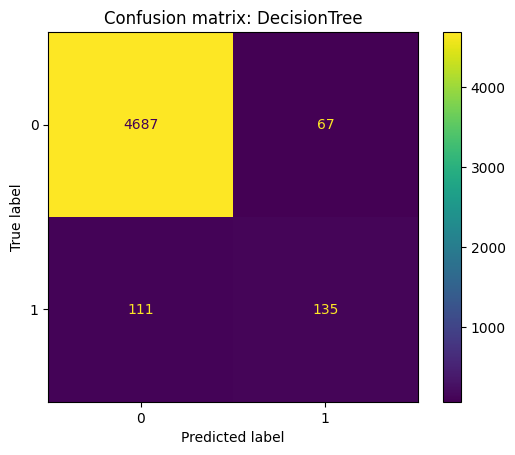

Saved to: C:\Users\cucumber\Desktop\Learnng\AI Agent\ai_agent_memerea\homeworks\HW06\artifacts\figures\DecisionTree.png
ROC curve saved to: C:\Users\cucumber\Desktop\Learnng\AI Agent\ai_agent_memerea\homeworks\HW06\artifacts\figures\DecisionTree_roc.png


In [25]:
results = []
results.append(
    final_evaluation("DecisionTree", best_dt, X_test, y_test,
                     is_binary=(len(np.unique(y_train)) == 2))
)

In [27]:
from sklearn.ensemble import RandomForestClassifier

rf_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [6, 10, None],
    "min_samples_leaf": [1, 5, 10],
    "max_features": ["sqrt", 0.5]   # ключевая лесная ручка
}

rf_gs = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    rf_param_grid,
    cv=5,
    scoring="f1" if len(np.unique(y_train)) == 2 else "f1_macro",
    n_jobs=-1
)

rf_gs.fit(X_train, y_train)

best_rf = rf_gs.best_estimator_
print("Best RF params:", rf_gs.best_params_)

C:\Users\cucumber\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best RF params: {'max_depth': None, 'max_features': 0.5, 'min_samples_leaf': 1, 'n_estimators': 200}



===== RandomForest (FINAL TEST) =====
Accuracy: 0.9758
F1: 0.6756
ROC-AUC: 0.9020
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      4754
           1       0.99      0.51      0.68       246

    accuracy                           0.98      5000
   macro avg       0.98      0.76      0.83      5000
weighted avg       0.98      0.98      0.97      5000



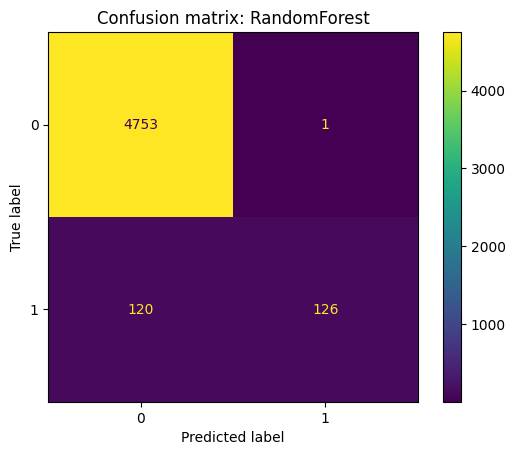

Saved to: C:\Users\cucumber\Desktop\Learnng\AI Agent\ai_agent_memerea\homeworks\HW06\artifacts\figures\RandomForest.png
ROC curve saved to: C:\Users\cucumber\Desktop\Learnng\AI Agent\ai_agent_memerea\homeworks\HW06\artifacts\figures\RandomForest_roc.png


In [28]:
results.append(
    final_evaluation("RandomForest", best_rf, X_test, y_test,
                     is_binary=(len(np.unique(y_train)) == 2))
)

C:\Users\cucumber\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best HistGB params: {'learning_rate': 0.1, 'max_depth': 7, 'max_iter': 100, 'min_samples_leaf': 10}

===== HistGradientBoosting (FINAL TEST) =====
Accuracy: 0.9794
F1: 0.7469
ROC-AUC: 0.8903
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      4754
           1       0.94      0.62      0.75       246

    accuracy                           0.98      5000
   macro avg       0.96      0.81      0.87      5000
weighted avg       0.98      0.98      0.98      5000



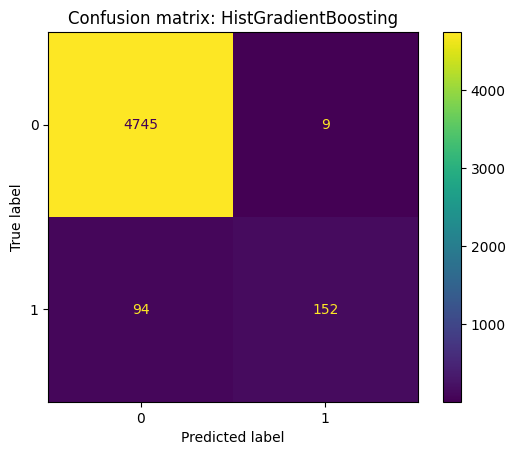

Saved to: C:\Users\cucumber\Desktop\Learnng\AI Agent\ai_agent_memerea\homeworks\HW06\artifacts\figures\HistGradientBoosting.png
ROC curve saved to: C:\Users\cucumber\Desktop\Learnng\AI Agent\ai_agent_memerea\homeworks\HW06\artifacts\figures\HistGradientBoosting_roc.png


In [22]:
from sklearn.ensemble import HistGradientBoostingClassifier

hgb_param_grid = {
    "max_depth": [3, 5, 7],
    "learning_rate": [0.05, 0.1],
    "max_iter": [100, 200],
    "min_samples_leaf": [10, 20]
}

hgb_gs = GridSearchCV(
    HistGradientBoostingClassifier(random_state=42),
    hgb_param_grid,
    cv=5,
    scoring="f1" if len(np.unique(y_train)) == 2 else "f1_macro",
    n_jobs=-1
)

hgb_gs.fit(X_train, y_train)

best_hgb = hgb_gs.best_estimator_
print("Best HistGB params:", hgb_gs.best_params_)


===== HistGradientBoosting (FINAL TEST) =====
Accuracy: 0.9794
F1: 0.7469
ROC-AUC: 0.8903
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      4754
           1       0.94      0.62      0.75       246

    accuracy                           0.98      5000
   macro avg       0.96      0.81      0.87      5000
weighted avg       0.98      0.98      0.98      5000



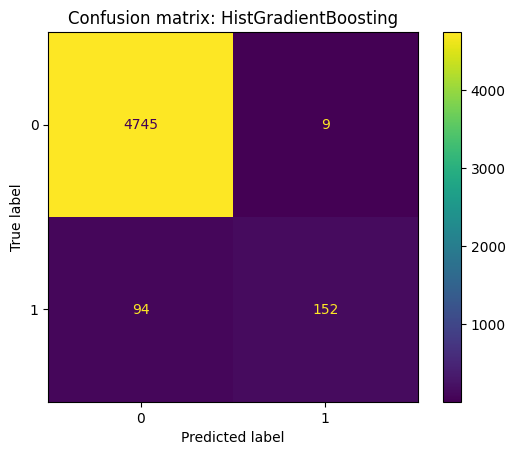

Saved to: C:\Users\cucumber\Desktop\Learnng\AI Agent\ai_agent_memerea\homeworks\HW06\artifacts\figures\HistGradientBoosting.png
ROC curve saved to: C:\Users\cucumber\Desktop\Learnng\AI Agent\ai_agent_memerea\homeworks\HW06\artifacts\figures\HistGradientBoosting_roc.png


In [29]:
results.append(
    final_evaluation("HistGradientBoosting", best_hgb, X_test, y_test,
                     is_binary=(len(np.unique(y_train)) == 2))
)


Top-10 важнейших признаков (permutation importance):
   feature  mean_importance       std
52     f52         0.027781  0.006216
57     f57         0.020620  0.008333
3       f3         0.015309  0.004296
37     f37         0.012917  0.002110
12     f12         0.012810  0.003428
24     f24         0.011016  0.004163
53     f53         0.010374  0.002277
35     f35         0.009021  0.003743
46     f46         0.008643  0.004002
40     f40         0.007918  0.004234


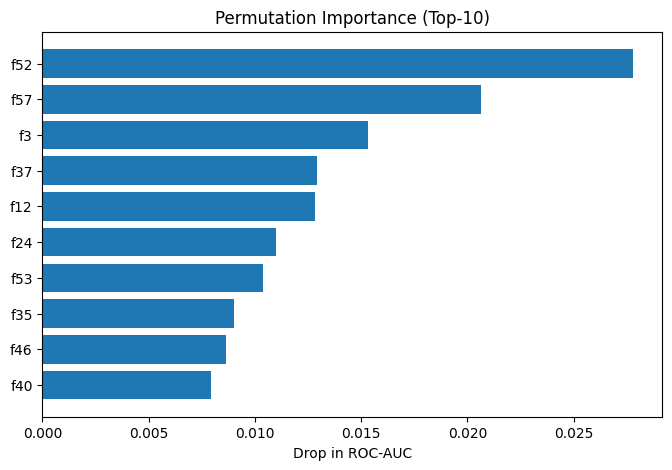

In [30]:
from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt

FIG_DIR = Path.cwd() / "artifacts" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

perm = permutation_importance(
    best_rf,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1,
    scoring="roc_auc"
)

# Собираем таблицу важности
feature_names = [f"f{i}" for i in range(X_test.shape[1])]

imp_df = pd.DataFrame({
    "feature": feature_names,
    "mean_importance": perm.importances_mean,
    "std": perm.importances_std
})

top10 = imp_df.sort_values("mean_importance", ascending=False).head(10)

print("\nTop-10 важнейших признаков (permutation importance):")
print(top10)

top10 = top10.sort_values("mean_importance")
plt.figure(figsize=(8,5))
plt.barh(top10["feature"], top10["mean_importance"])
plt.title("Permutation Importance (Top-10)")
plt.xlabel("Drop in ROC-AUC")
out_path = FIG_DIR / "permutation_importance_top10.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
plt.close()

«Permutation importance для лучшей модели (RandomForest, ROC-AUC = 0.902) показывает, что около 5–6 признаков (f52, f57, f3, f37, f12, f24) определяют основную часть качества классификации, тогда как остальные признаки вносят второстепенный вклад. Это свидетельствует о компактном и интерпретируемом ядре информативных переменных.»